# Mapping your cells onto the autoimmune B / CD4+ T cell atlas

Yasumizu et al., *Cell Genomics* 2024 (CD4+ T cells) and the companion B cell study.
This notebook takes a raw-count query, transfers the atlas `cluster_L1` / `cluster_L2`
labels onto it, and places the query on the published atlas UMAP.

## The one thing that matters: preprocess the query the way the reference was built

Symphony projects a query by scaling it with the reference's own per-gene statistics and
applying the reference's PCA loadings. That only works if the query went through the same
transformations as the reference. These atlases were built as

```
normalize_total(target_sum=1e4) -> log1p
  -> regress_out([total_counts, pct_counts_mt, S_score, G2M_score]) -> scale -> PCA -> Harmony
```

so `reference.var['mean']` / `['std']` describe the data **after** that covariate regression.
A query that stops at `log1p` is on a different scale, and the projection inherits the
difference. The reference therefore ships the coefficients it was regressed with
(`reference.varm['regress_beta']`) and the full recipe
(`reference.uns['symphony_query_preprocessing']`); `prepare_query()` replays them on your data.

The last section shows what the same query looks like when this step is skipped.

Everything below runs on a public dataset (10x 10k PBMC, 5' v2), so you can execute the
notebook as-is before pointing it at your own cells.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import symphonypy as sp

import screfmapping_symphonypy as srm

REFERENCE_H5AD = 'autoimmune_bcell_symphony_reference_v2.h5ad'
# repository layout keeps the gene list in data/, the Figshare bundle keeps it alongside the h5ad
CELL_CYCLE_GENES = next(p for p in [Path('data/regev_lab_cell_cycle_genes.txt'),
                                    Path('regev_lab_cell_cycle_genes.txt')] if p.exists())
OUT = Path('output')
OUT.mkdir(exist_ok=True)

np.random.seed(0)
sc.settings.verbosity = 1
from importlib.metadata import version
print('scanpy', sc.__version__, '| symphonypy', version('symphonypy'))

scanpy 1.11.4 | symphonypy 0.2.2


## 1. A query to map

10x 10k PBMC (5' v2, GRCh38), clustered here and restricted to the B cell clusters.
For your own data, isolate the lineage first - Azimuth, CellTypist, or your own annotation -
and keep **raw counts** with human gene symbols.

Sequencing depth is worth a thought when choosing what to map. The covariate regression
carries the reference's coefficients for `total_counts`, so a query whose libraries are far
shallower than the reference is corrected outside the range those coefficients were fitted on.
The atlas was built from 5'-end libraries with paired receptor sequencing, so a 5' query of a
similar depth is the closest match: on this dataset nearly every reference gene is present and
the per-cell distances to the reference are markedly lower than for a shallower 3' library.
The check below prints the query and reference covariate medians side by side.

To map CD4+ T cells instead, keep the T cell clusters here and point `REFERENCE_H5AD` at the
CD4+ T cell reference; nothing else in the notebook changes.

In [2]:
from urllib.request import urlretrieve

URL = ('https://cf.10xgenomics.com/samples/cell-vdj/5.0.0/sc5p_v2_hs_PBMC_10k/'
       'sc5p_v2_hs_PBMC_10k_filtered_feature_bc_matrix.h5')
h5 = Path('data/sc5p_v2_hs_PBMC_10k_filtered_feature_bc_matrix.h5')
h5.parent.mkdir(exist_ok=True)
if not h5.exists():
    urlretrieve(URL, h5)

pbmc = sc.read_10x_h5(h5)
pbmc.var_names_make_unique()
sc.pp.filter_cells(pbmc, min_genes=200)
pbmc

AnnData object with n_obs × n_vars = 10529 × 36601
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [3]:
# standard clustering, only to isolate the B cells
clustered = pbmc.copy()
sc.pp.normalize_total(clustered, target_sum=1e4)
sc.pp.log1p(clustered)
normalised = clustered.copy()
sc.pp.highly_variable_genes(clustered, n_top_genes=2000)
clustered = clustered[:, clustered.var.highly_variable].copy()
sc.pp.scale(clustered, max_value=10)
sc.tl.pca(clustered, random_state=0)
sc.pp.neighbors(clustered, random_state=0)
sc.tl.leiden(clustered, resolution=1.0, random_state=0, flavor='igraph', n_iterations=2)
normalised.obs['leiden'] = clustered.obs['leiden'].values

def cluster_means(genes):
    present = [g for g in genes if g in normalised.var_names]
    x = normalised[:, present].X
    x = x.toarray() if hasattr(x, 'toarray') else np.asarray(x)
    return pd.DataFrame(x).groupby(normalised.obs['leiden'].to_numpy()).mean().mean(axis=1)

score = pd.DataFrame({
    'B': cluster_means(['MS4A1', 'CD79A', 'CD79B', 'BANK1']),
    'other': cluster_means(['CD3E', 'CD3D', 'LYZ', 'NKG7', 'GNLY', 'PPBP']),
})
score['is_B'] = (score['B'] > 0.5) & (score['B'] > score['other'])
display(score.round(2))

,B,other,is_B
0,0.02,0.79,False
1,0.01,0.80,False
10,0.04,1.19,False
11,0.07,0.71,False
12,2.31,0.06,True
13,0.80,0.03,True
14,0.08,0.78,False
15,0.02,1.23,False
16,0.04,0.68,False
17,0.14,0.51,False


In [4]:
b_clusters = score.index[score['is_B']]
selected = normalised.obs_names[normalised.obs['leiden'].isin(b_clusters)]
print(f'{len(selected)} cells in leiden clusters {list(b_clusters)}')

# drop the cells that still carry T-cell transcripts on top of the cluster-level call
tcr = normalised[selected, [g for g in ['CD3E', 'CD3D'] if g in normalised.var_names]].X
tcr = tcr.toarray() if hasattr(tcr, 'toarray') else np.asarray(tcr)
keep = selected[(tcr < 0.5).all(axis=1)]
print(f'{len(selected) - len(keep)} dropped as CD3D/CD3E positive')

query_raw = pbmc[keep].copy()
print(f'{query_raw.n_obs} B cells')
print('counts are integers:', bool((query_raw.X.data % 1 == 0).all()))

1017 cells in leiden clusters ['12', '13', '2']
111 dropped as CD3D/CD3E positive
906 B cells
counts are integers: True


## 2. Preprocess the query the way the reference was built

`prepare_query()` reads the recipe out of the reference and replays it: QC covariates on the
full gene set, CP10K + `log1p`, removal of immunoglobulin V/C genes, cell-cycle scoring, and
residualisation of the reference gene set with `reference.varm['regress_beta']`. It returns the
matrix Symphony expects.

In [5]:
reference = sc.read_h5ad(REFERENCE_H5AD)
for step in reference.uns['symphony_query_preprocessing']['steps']:
    print('-', step)

- raw counts (gene symbols; collapse duplicate symbols by summing)
- sc.pp.calculate_qc_metrics(qc_vars=['mt'] with MT- prefix) on ALL genes -> total_counts, pct_counts_mt
- sc.pp.normalize_total(target_sum=1e4); sc.pp.log1p
- drop genes starting with IGKV/IGLV/IGHV/IGLC
- sc.tl.score_genes_cell_cycle with regev_lab_cell_cycle_genes.txt (first 43 = S, rest = G2M) -> S_score, G2M_score
- for the 1,608 reference genes: resid = log1p - [1, total_counts, pct_counts_mt, S_score, G2M_score] @ varm['regress_beta'].T; missing genes -> 0
- AnnData(resid) with uns['log1p'] -> symphonypy.tl.map_embedding(query, reference, key=None or batch) -> transfer_labels_kNN -> ingest


In [6]:
query = srm.prepare_query(
    query_raw,
    reference,
    cell_cycle_genes=CELL_CYCLE_GENES,
    batch_key=None,       # single library; use your batch column when you have several
)
query

reference genes: 1608 | found in query: 1608 | missing (set to the reference mean): 0


AnnData object with n_obs × n_vars = 906 × 1608
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase'
    uns: 'log1p', 'screfmapping_query_preprocessing'

### Are the covariates on the same scale as the reference?

The regression coefficients were fitted on the reference's `total_counts`, `pct_counts_mt`,
`S_score` and `G2M_score`. They transfer cleanly when the query sits in a similar range.
A query that is much shallower or much deeper than the reference gets a correspondingly
different correction, and the projection is pulled with it. Check this before you trust the
labels; if the medians are far apart, read `symphony_dist` and the marker panels below with
that in mind.

In [7]:
summary = reference.uns['symphony_query_preprocessing'].get('reference_covariate_summary')
rows = {'query': query.obs[srm.COVARIATES].median()}
if summary:
    rows['reference'] = pd.DataFrame(summary).loc['50%', srm.COVARIATES]
pd.DataFrame(rows).T.round(3)

,total_counts,pct_counts_mt,S_score,G2M_score
query,4968.5,4.39,-0.077,-0.081
reference,4621.0,3.56,-0.083,-0.075


## 3. Map and transfer labels

In [8]:
query = srm.map_query(
    query,
    reference,
    key=None,                              # pass your batch column name when you have one
    labels=('cluster_L1', 'cluster_L2'),
)

pd.DataFrame({
    'n_cells': query.obs['cluster_L2'].value_counts(),
    'percent': (query.obs['cluster_L2'].value_counts(normalize=True) * 100).round(1),
})

,n_cells,percent
cluster_L2,,
Bnaive,596,65.8
Busm,83,9.2
Bsm,52,5.7
Bnaive SOX4,41,4.5
Bmem int,35,3.9
ABC,34,3.8
Bnaive preASC,27,3.0
ASC,19,2.1
Bsm FCER2,14,1.5


## 4. Where the query lands on the atlas

`ingest` puts the query into the published atlas UMAP, so the query can be read against the
reference cells directly. `symphony_dist` is the per-cell distance to the reference
neighbourhood: high values mark cells the atlas has no good match for.

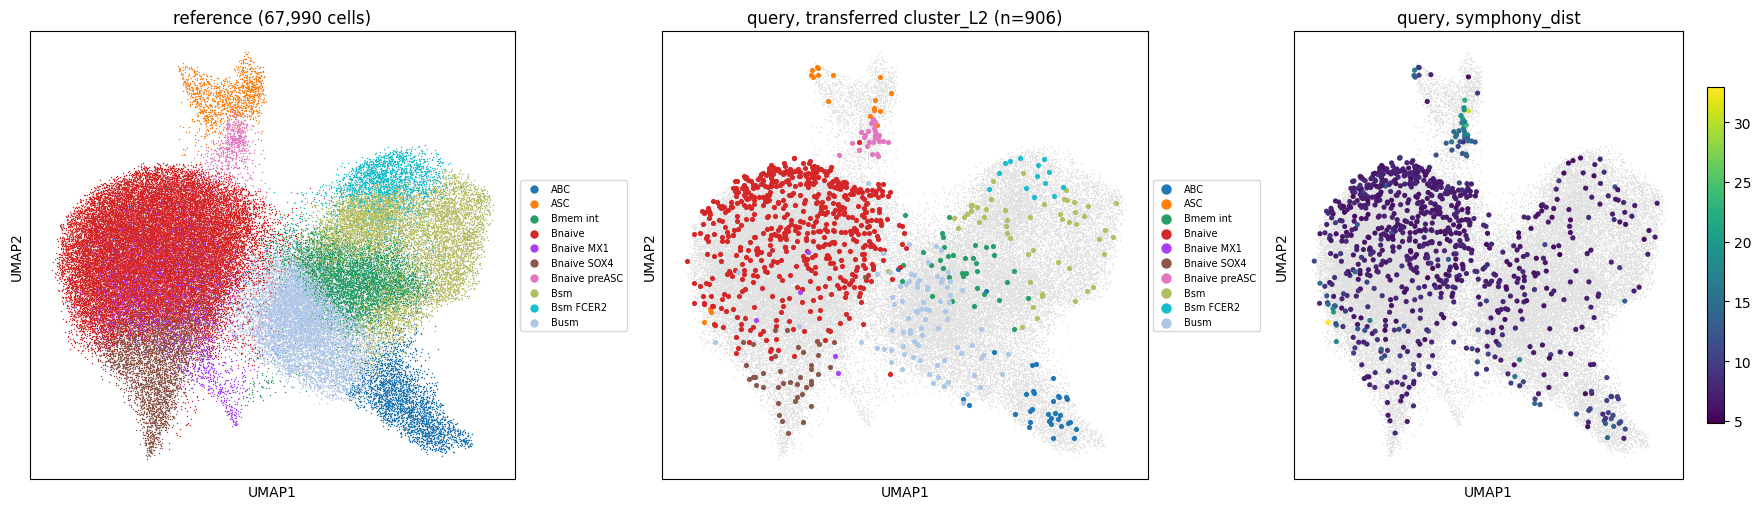

In [9]:
ref_umap = np.asarray(reference.obsm['X_umap'])
q_umap = np.asarray(query.obsm['X_umap'])
labels = query.obs['cluster_L2'].astype(str)
ref_labels = reference.obs['cluster_L2'].astype(str)

# use the atlas palette in both panels so the colours mean the same thing
categories = list(reference.obs['cluster_L2'].cat.categories)
stored_colors = list(reference.uns.get('cluster_L2_colors', []))
palette = (dict(zip(categories, stored_colors)) if len(stored_colors) == len(categories)
           else {c: f'C{i}' for i, c in enumerate(categories)})

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
for ax in axes:
    ax.scatter(ref_umap[:, 0], ref_umap[:, 1], s=1, c='#e0e0e0', linewidths=0, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')

for label in categories:
    m = (ref_labels == label).to_numpy()
    axes[0].scatter(ref_umap[m, 0], ref_umap[m, 1], s=1, c=palette[label],
                    linewidths=0, label=label, rasterized=True)
axes[0].set_title(f'reference ({reference.n_obs:,} cells)')
axes[0].legend(markerscale=6, fontsize=7, loc='center left', bbox_to_anchor=(1.0, 0.5))

for label in categories:
    m = (labels == label).to_numpy()
    if not m.any():
        continue
    axes[1].scatter(q_umap[m, 0], q_umap[m, 1], s=14, c=palette[label],
                    linewidths=0, label=label, rasterized=True)
axes[1].set_title(f'query, transferred cluster_L2 (n={query.n_obs})')
axes[1].legend(markerscale=2, fontsize=7, loc='center left', bbox_to_anchor=(1.0, 0.5))

dist = axes[2].scatter(q_umap[:, 0], q_umap[:, 1], s=14, c=query.obs['symphony_dist'],
                       cmap='viridis', linewidths=0, rasterized=True)
axes[2].set_title('query, symphony_dist')
fig.colorbar(dist, ax=axes[2], shrink=0.75)
fig.tight_layout()
fig.savefig(OUT / 'query_on_reference_umap.pdf', bbox_inches='tight')
plt.show()

## 5. Do the labels agree with the markers?

The transferred label is only as good as the projection, so read it against the query's own
expression. `TCL1A`, `IGHD` and `FCER2` should sit on the naive side, `CD27` and `TNFRSF13B`
on the memory side, and `MZB1` on the antibody-secreting island.

The markers of the rarer states are left to the dot plot below. A healthy donor carries very
few atypical B cells or interferon-activated B cells, so `ITGAX` or `MX1` cannot help but look
like scattered dots on a UMAP, while the dot plot still shows them as mean expression and
percent positive per state.

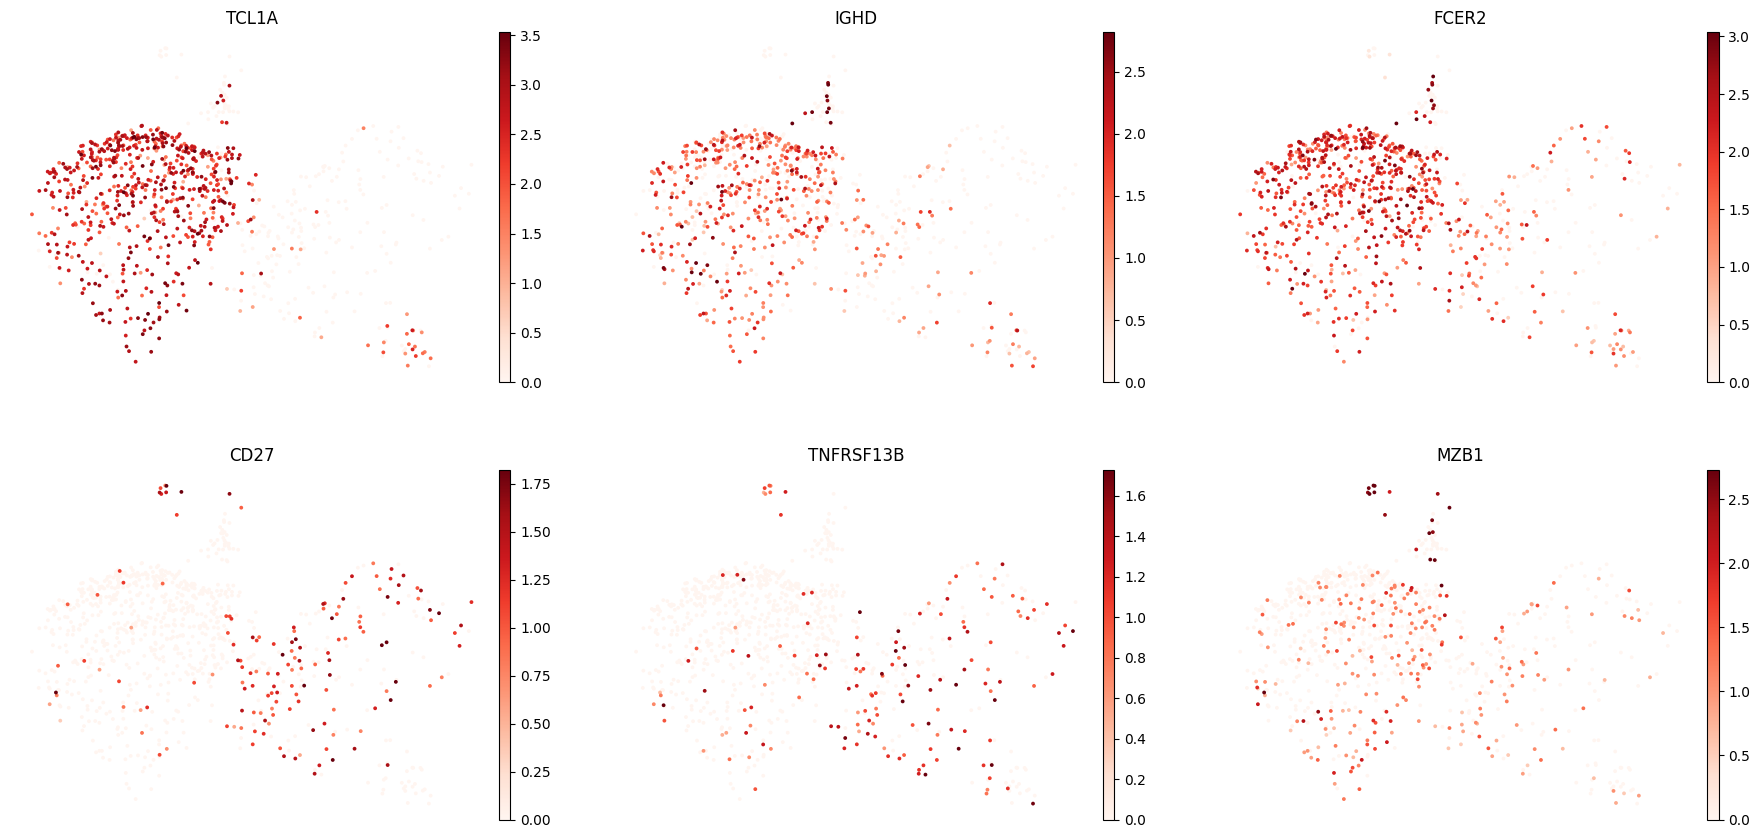

In [10]:
MARKERS = ['TCL1A', 'IGHD', 'FCER2',        # naive
           'CD27', 'TNFRSF13B',             # memory
           'MZB1']                          # antibody-secreting

expression = query_raw.copy()
expression.var_names_make_unique()
sc.pp.normalize_total(expression, target_sum=1e4)
sc.pp.log1p(expression)
expression = expression[query.obs_names].copy()
expression.obs['cluster_L2'] = query.obs['cluster_L2'].values
expression.obsm['X_umap'] = q_umap          # the published atlas UMAP

sc.pl.umap(expression, color=[g for g in MARKERS if g in expression.var_names],
           cmap='Reds', vmax='p99', ncols=3, frameon=False, size=30,
           save='_query_markers.pdf')

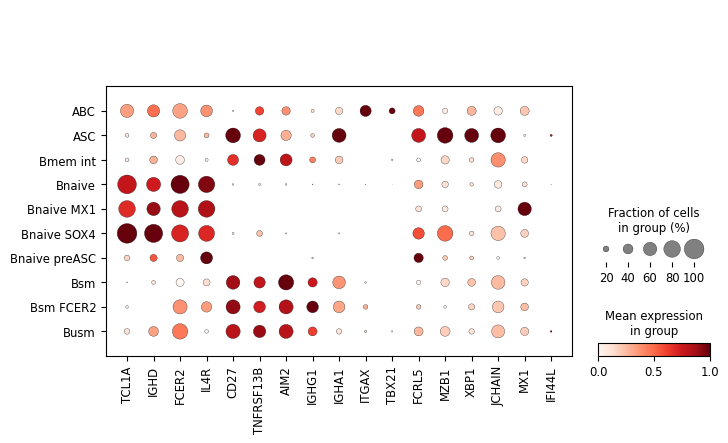

In [11]:
panel = ['TCL1A', 'IGHD', 'FCER2', 'IL4R',        # naive
         'CD27', 'TNFRSF13B', 'AIM2',             # memory
         'IGHG1', 'IGHA1',                        # class-switched
         'ITGAX', 'TBX21', 'FCRL5',               # atypical
         'MZB1', 'XBP1', 'JCHAIN',                # antibody-secreting
         'MX1', 'IFI44L']                         # interferon
panel = [g for g in panel if g in expression.var_names]
sc.pl.dotplot(expression, panel, groupby='cluster_L2', standard_scale='var',
              swap_axes=False, show=True)

## 6. What happens if the query is not matched to the reference

The same cells, mapped after `log1p` alone - the step that replays the reference's covariate
regression is skipped. Everything else is identical: same cells, same reference, same
parameters. The projection shifts, and with it the labels.

In [12]:
naive = query_raw.copy()
naive.var_names_make_unique()
sc.pp.normalize_total(naive, target_sum=1e4)
sc.pp.log1p(naive)
naive = naive[:, [g for g in reference.var_names if g in naive.var_names]].copy()
missing = [g for g in reference.var_names if g not in naive.var_names]
if missing:
    import anndata as ad
    filler = ad.AnnData(np.zeros((naive.n_obs, len(missing)), dtype=np.float32),
                        obs=naive.obs.copy(), var=pd.DataFrame(index=pd.Index(missing)))
    naive = ad.concat([naive, filler], axis=1, merge='first')
naive = naive[:, reference.var_names].copy()
naive.uns['log1p'] = {'base': None}

sp.tl.map_embedding(naive, reference, key=None)
sp.tl.transfer_labels_kNN(naive, reference, ref_labels=['cluster_L2'],
                          query_labels=['cluster_L2'], n_neighbors=5, weights='distance')
sp.tl.ingest(naive, reference)

print('cells given the same label either way:',
      f"{(naive.obs['cluster_L2'].astype(str).to_numpy() == labels.to_numpy()).mean():.1%}")

cells given the same label either way: 84.4%


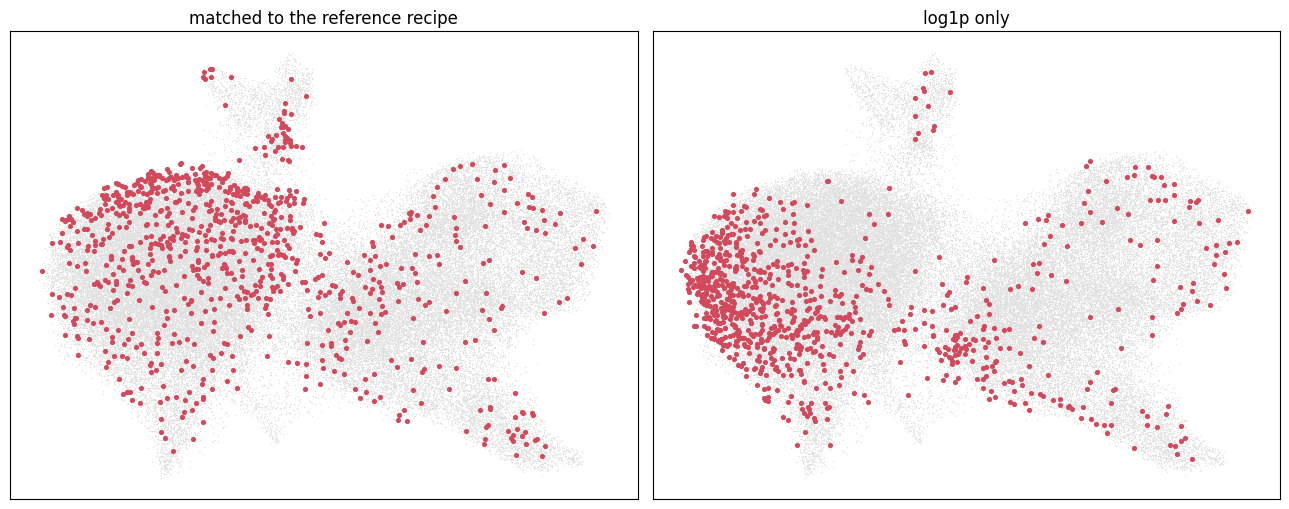

log1p only,ABC,ASC,Bmem int,Bnaive,Bnaive MX1,Bnaive SOX4,Bnaive preASC,Bsm,Bsm FCER2,Busm
matched,,,,,,,,,,
ABC,24,0,0,2,1,2,0,1,0,4
ASC,0,9,0,7,0,0,3,0,0,0
Bmem int,1,0,7,3,0,0,0,0,0,24
Bnaive,2,0,0,562,3,25,0,1,0,3
Bnaive MX1,0,0,0,2,3,0,0,0,0,0
Bnaive SOX4,0,0,0,5,0,35,0,0,0,1
Bnaive preASC,0,0,0,21,1,2,0,0,0,3
Bsm,0,0,4,0,0,0,0,40,6,2
Bsm FCER2,0,0,0,1,0,0,0,2,11,0


In [13]:
n_umap = np.asarray(naive.obsm['X_umap'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, coords, title in [(axes[0], q_umap, 'matched to the reference recipe'),
                          (axes[1], n_umap, 'log1p only')]:
    ax.scatter(ref_umap[:, 0], ref_umap[:, 1], s=1, c='#e0e0e0', linewidths=0, rasterized=True)
    ax.scatter(coords[:, 0], coords[:, 1], s=14, c='#d1495b', linewidths=0, rasterized=True)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig.savefig(OUT / 'preprocessing_comparison_umap.pdf', bbox_inches='tight')
plt.show()

pd.crosstab(pd.Series(labels.to_numpy(), name='matched'),
            pd.Series(naive.obs['cluster_L2'].astype(str).to_numpy(), name='log1p only'))

## 7. Save

In [14]:
out = query.obs[['cluster_L1', 'cluster_L2', 'symphony_dist']].copy()
out[['umap_x', 'umap_y']] = q_umap
out.to_csv(OUT / 'query_labels.tsv.gz', sep='\t')
query.write_h5ad(OUT / 'query_mapped.h5ad', compression='gzip')
print('wrote', OUT / 'query_labels.tsv.gz', 'and', OUT / 'query_mapped.h5ad')

wrote output/query_labels.tsv.gz and output/query_mapped.h5ad


## Using it on your own data

Replace section 1 with your own object. The requirements are:

* **raw counts** in `X` (not normalised, not scaled), human gene symbols in `var_names`
  (duplicate symbols are summed), one row per cell;
* the cells restricted to the lineage of the reference beforehand;
* a library/batch column in `obs` when the query has more than one library - pass its name as
  `batch_key=` to `prepare_query()` and as `key=` to `map_query()`, which lets Symphony
  correct the query batches against the reference. `key=None` is for a single library.

Reference genes missing from the query are held at the reference mean, so a query with fewer
genes still maps; `prepare_query()` prints how many were found. Sequencing depth matters more
than gene coverage here: dropping the ~280 genes an older annotation lacks barely moves the
result, while a query several times shallower than the reference is corrected outside the
range the coefficients were fitted on. Mapping is deterministic given the same reference,
`key` and `n_neighbors`.

## Citation

Yasumizu, Y. et al. Single-cell transcriptome landscape of circulating CD4+ T cell
populations in autoimmune diseases. *Cell Genomics* (2024).
https://doi.org/10.1016/j.xgen.2023.100473